<a href="https://colab.research.google.com/github/TomatoesSuck/Voice-Activity-Detection-Compression/blob/main/vad_experiment_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAD Compression Experiment

Benchmarks four compression strategies on `speechbrain/vad-crdnn-libriparty` (CRDNN architecture).

| Strategy | Method |
|---|---|
| FP32 Baseline | No compression |
| PTQ | Dynamic INT8 quantization (`nn.Linear` only) |
| QAT | FakeQuant fine-tuning on DNN → INT8 |
| PTQ+QAT | FakeQuant fine-tuning on all sub-modules → INT8 |

**Metrics**: model size (MB) · latency median / P95 (ms) · frame-level F1 on LibriParty.

In [ ]:
import subprocess, os
from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/VAD_Compression"
os.makedirs(SAVE_DIR, exist_ok=True)

BRANCH = 'develop'
subprocess.run(
    f"pip install -q git+https://github.com/speechbrain/speechbrain.git@{BRANCH}",
    shell=True,
)
print(f"Results will be saved at: {SAVE_DIR}")

Mounted at /content/drive
Results will be saved at: /content/drive/MyDrive/VAD_Compression


## Data Configuration

- `"demo"` — single example WAV, no download
- `"small"` — LibriParty first 20 eval sessions *(recommended)*
- `"full"` — full LibriParty ~10 GB

Resolution order: Drive cache → `/content` → Drive tar.gz → fresh Dropbox download.

In [ ]:
import glob

DATA_MODE = "small"  # "demo" | "small" | "full"

DRIVE_LIBRIPARTY = os.path.join(SAVE_DIR, "LibriParty")
LOCAL_LIBRIPARTY = "/content/LibriParty"


def libriparty_is_valid(path):
    """Return True if path contains at least one dataset/eval/session_* directory."""
    return (
        os.path.isdir(os.path.join(path, "dataset", "eval"))
        and len(glob.glob(os.path.join(path, "dataset", "eval", "session_*"))) > 0
    )


if DATA_MODE == "demo":
    print("Mode: Demo — example audio only")
    !wget -q -O /content/vad_test1.wav "https://www.dropbox.com/scl/fi/vvffxbkkuv79g0d4c7so3/example_vad_music.wav?rlkey=q5m5wc6y9fsfvt43x5yy8ohrf&dl=1"
    AUDIO_FILES = ["/content/vad_test1.wav"]
    LIBRIPARTY_DIR = None

elif DATA_MODE in ("small", "full"):
    print(f"Mode: {DATA_MODE.capitalize()} — LibriParty")
    if libriparty_is_valid(DRIVE_LIBRIPARTY):
        LIBRIPARTY_DIR = DRIVE_LIBRIPARTY
        print(f"Found in Drive: {LIBRIPARTY_DIR}")
    elif libriparty_is_valid(LOCAL_LIBRIPARTY):
        LIBRIPARTY_DIR = LOCAL_LIBRIPARTY
        print(f"Found in /content: {LIBRIPARTY_DIR}")
    else:
        drive_tar = os.path.join(SAVE_DIR, "LibriParty.tar.gz")
        local_tar = "/content/LibriParty.tar.gz"
        if os.path.exists(drive_tar):
            print("Extracting from Drive tar.gz ...")
            !tar -xzf "{drive_tar}" -C /content/
            LIBRIPARTY_DIR = LOCAL_LIBRIPARTY
        elif os.path.exists(local_tar):
            print("Extracting local tar.gz ...")
            !tar -xzf /content/LibriParty.tar.gz -C /content/
            LIBRIPARTY_DIR = LOCAL_LIBRIPARTY
        else:
            print("Downloading from Dropbox ...")
            !wget -O /content/LibriParty.tar.gz "https://www.dropbox.com/s/ebo987wu3hie3zm/LibriParty.tar.gz?dl=1"
            !tar -xzf /content/LibriParty.tar.gz -C /content/
            LIBRIPARTY_DIR = LOCAL_LIBRIPARTY

    assert libriparty_is_valid(LIBRIPARTY_DIR), \
        f"LibriParty not valid at {LIBRIPARTY_DIR}"
    AUDIO_FILES = None
    print(f"LibriParty ready at: {LIBRIPARTY_DIR}")

print(f"\nData mode: {DATA_MODE}")

Mode: Small — LibriParty
--2026-04-17 18:25:00--  https://www.dropbox.com/s/ebo987wu3hie3zm/LibriParty.tar.gz?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/53mn0n0v50gmm3k5w82ba/LibriParty.tar.gz?rlkey=nti1de8m76unze1onwikarbxc&dl=1 [following]
--2026-04-17 18:25:01--  https://www.dropbox.com/scl/fi/53mn0n0v50gmm3k5w82ba/LibriParty.tar.gz?rlkey=nti1de8m76unze1onwikarbxc&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc3a84ffa56c8a12dc0edbf43437.dl.dropboxusercontent.com/cd/0/inline/C-wIWaoLe93jQVKl73AwQU0Emws6rwuOS6I1HgDMQ9CRy2vCLibMGeQE0VZ-i6dsh04WQlnDUdUyTnsNBJQkowN3bDvMAineB4dp-JwCc4vr0DS5o_iEmyjFnJb8dA9zFUlgQ15gadvysrPjywD_2ZDe/file?dl=1# [following]
--2026-04-17 18:25:01--  https://uc3a84ff

## Imports, Backend, and Helpers

- Backend: `fbgemm` (x86) / `qnnpack` (ARM) — must be set before any quantized op.
- `get_wrapper_size_mb` — serialises only `mods['model']` to get accurate disk size.
- `measure_latency` — median + P95 over 100 runs, single-threaded CPU.
- `global_warmup` — pre-warms FFT / mel / thread caches before any timing.
- `quantize_all_paths` — quantizes both `mods['model']` and sub-module handles so F1 eval and latency use the same INT8 weights.

In [ ]:
import time, copy, json, random, platform
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from speechbrain.inference.VAD import VAD

if platform.machine() in ("arm64", "aarch64"):
    torch.backends.quantized.engine = "qnnpack"
else:
    torch.backends.quantized.engine = "fbgemm"
print(f"Quantized engine: {torch.backends.quantized.engine} (machine={platform.machine()})")


def get_wrapper_size_mb(vad_obj, verbose=False):
    """Serialise mods['model'] state_dict to a temp file and return file size in MB."""
    tmp = "/tmp/_tmp_vad_model.pt"
    torch.save(vad_obj.mods['model'].state_dict(), tmp)
    size_mb = os.path.getsize(tmp) / (1024 ** 2)
    if verbose:
        sd = vad_obj.mods['model'].state_dict()
        dtypes, skipped = {}, 0
        for v in sd.values():
            if not torch.is_tensor(v):
                skipped += 1
                continue
            key = str(v.dtype)
            dtypes[key] = dtypes.get(key, 0) + v.numel()
        print(f"  [size debug] {len(sd)} keys ({skipped} non-tensor skipped)")
        for dt, n in sorted(dtypes.items(), key=lambda kv: -kv[1]):
            print(f"    {dt}: {n} params")
    os.remove(tmp)
    return round(size_mb, 3)


def measure_latency(model, input_tensor, n_warmup=30, n_runs=100, device="cpu"):
    """Return (median_ms, std_ms, p95_ms) over n_runs single-threaded CPU forward passes."""
    model.eval()
    model = model.to(device)
    x = input_tensor.to(device)
    if device == "cpu":
        torch.set_num_threads(1)
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(x)
        times = []
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _ = model(x)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)
    model = model.to("cpu")
    arr = np.array(times)
    return (
        round(float(np.median(arr)), 3),
        round(float(arr.std()), 3),
        round(float(np.percentile(arr, 95)), 3),
    )


def global_warmup(model, input_tensor, n_iters=50):
    """Run n_iters un-timed forward passes to stabilise FFT/mel/thread-pool caches."""
    model.eval()
    with torch.no_grad():
        for _ in range(n_iters):
            _ = model(input_tensor)


def quantize_all_paths(vad_obj, quant_spec, dtype=torch.qint8):
    """Apply quantize_dynamic to mods['model'] and to each of mods['cnn'/'rnn'/'dnn']."""
    vad_obj.mods['model'] = torch.quantization.quantize_dynamic(
        vad_obj.mods['model'], qconfig_spec=quant_spec, dtype=dtype
    )
    for name in ('cnn', 'rnn', 'dnn'):
        vad_obj.mods[name] = torch.quantization.quantize_dynamic(
            vad_obj.mods[name], qconfig_spec=quant_spec, dtype=dtype
        )
    return vad_obj

Quantized engine: fbgemm (machine=x86_64)


## FP32 Baseline — Load Model and Build Wrapper

`CRDNNWrapper` assembles the VAD sub-modules into one `nn.Module` with a standard `forward(wav)` signature,
enabling unified latency benchmarking and gradient-based fine-tuning.

In [ ]:
vad_fp32 = VAD.from_hparams(
    source="speechbrain/vad-crdnn-libriparty",
    savedir=os.path.join(SAVE_DIR, "pretrained_vad"),
)
vad_fp32.mods['model'].eval()
print("FP32 model loaded.")
print(f"Submodules: {list(vad_fp32.mods.keys())}")


class CRDNNWrapper(nn.Module):
    """Single nn.Module wrapping the full VAD pipeline: wav → features → CNN → RNN → DNN → logits."""

    def __init__(self, vad_obj):
        super().__init__()
        self.compute_features = vad_obj.mods['compute_features']
        self.mean_var_norm    = vad_obj.mods['mean_var_norm']
        self.cnn              = vad_obj.mods['cnn']
        self.rnn              = vad_obj.mods['rnn']
        self.dnn              = vad_obj.mods['dnn']

    def forward(self, wav):
        """Input: wav [B, T_samples] at 16 kHz. Output: logits [B, T_frames, 1]."""
        feats = self.compute_features(wav)
        if feats.dim() == 4:
            feats = feats.mean(-1)
        feats = self.mean_var_norm(
            feats, torch.ones(feats.shape[0], device=feats.device)
        )
        cnn_out = self.cnn(feats)
        B, T = cnn_out.shape[0], cnn_out.shape[1]
        rnn_out, _ = self.rnn(cnn_out.reshape(B, T, -1))
        return self.dnn(rnn_out)


wrapper_fp32 = CRDNNWrapper(vad_fp32)
wrapper_fp32.eval()
DUMMY_WAV = torch.randn(1, 48000)  # 3 s at 16 kHz
with torch.no_grad():
    test_out = wrapper_fp32(DUMMY_WAV)
print(f"Wrapper test OK — output shape: {test_out.shape}")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/vad-crdnn-libriparty' if not cached


hyperparams.yaml: 0.00B [00:00, ?B/s]

INFO:speechbrain.utils.fetching:Fetch model.ckpt: Fetching from HuggingFace Hub 'speechbrain/vad-crdnn-libriparty' if not cached


model.ckpt:   0%|          | 0.00/453k [00:00<?, ?B/s]

INFO:speechbrain.utils.fetching:Fetch mean_var_norm.ckpt: Fetching from HuggingFace Hub 'speechbrain/vad-crdnn-libriparty' if not cached


mean_var_norm.ckpt:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: model, mean_var_norm


FP32 model loaded.
Submodules: ['compute_features', 'model', 'cnn', 'rnn', 'dnn', 'mean_var_norm']
Wrapper test OK — output shape: torch.Size([1, 301, 1])


## FP32 Baseline Benchmarking

`global_warmup` is called **once here**, before any model is timed, so all strategies start from the same steady-state cache.

In [ ]:
print("Global warmup ...")
global_warmup(wrapper_fp32, DUMMY_WAV, n_iters=50)

fp32_size = get_wrapper_size_mb(vad_fp32, verbose=True)
fp32_latency_median, fp32_latency_std, fp32_latency_p95 = measure_latency(
    wrapper_fp32, DUMMY_WAV, device="cpu"
)

print("=" * 50)
print("FP32 Baseline")
print("=" * 50)
print(f"  Size    : {fp32_size} MB")
print(f"  Latency : {fp32_latency_median} ms  (std {fp32_latency_std}, p95 {fp32_latency_p95})")

Global warmup ...
  [size debug] 49 keys (0 non-tensor skipped)
    torch.float32: 109808 params
    torch.int64: 2 params
FP32 Baseline
  Size    : 0.435 MB
  Latency : 49.761 ms  (std 13.191, p95 80.693)


## PTQ — Post-Training Dynamic Quantization

- Converts `nn.Linear` weight matrices to INT8 at load time; activations are dequantized on the fly.
- GRU and Conv2d are **not** supported by `quantize_dynamic`, so only DNN layers go INT8.

In [ ]:
from torch.ao.nn.quantized.dynamic import Linear as QDynLinear

QUANT_SPEC = {nn.Linear}


def count_linear_params(module):
    """Return (linear_params, total_params) for a module, counting QDynLinear by unpacking packed weights."""
    total = sum(p.numel() for p in module.parameters())
    linear_params = 0
    for m in module.modules():
        if isinstance(m, QDynLinear):
            w, b = m._packed_params._weight_bias()
            linear_params += w.numel() + (b.numel() if b is not None else 0)
        elif isinstance(m, nn.Linear):
            linear_params += sum(p.numel() for p in m.parameters(recurse=False))
    return linear_params, total


vad_ptq = copy.deepcopy(vad_fp32)
vad_ptq = quantize_all_paths(vad_ptq, QUANT_SPEC)

wrapper_ptq = CRDNNWrapper(vad_ptq)
wrapper_ptq.eval()

q_params, t_params = count_linear_params(vad_ptq.mods['model'])
print(f"PTQ coverage: {q_params}/{t_params} params quantized ({100*q_params/max(t_params,1):.1f}%)")

ptq_size = get_wrapper_size_mb(vad_ptq, verbose=True)
ptq_latency_median, ptq_latency_std, ptq_latency_p95 = measure_latency(
    wrapper_ptq, DUMMY_WAV, device="cpu"
)

print("=" * 50)
print("PTQ")
print("=" * 50)
print(f"  Size    : {ptq_size} MB  ({round((1-ptq_size/fp32_size)*100,1)}% reduction)")
print(f"  Latency : {ptq_latency_median} ms  (std {ptq_latency_std}, p95 {ptq_latency_p95})")
print(f"  Speedup : {round(fp32_latency_median/ptq_latency_median, 2)}x")

PTQ coverage: 1328/108416 params quantized (1.2%)
  [size debug] 56 keys (6 non-tensor skipped)
    torch.float32: 108483 params
    torch.int64: 5 params


/tmp/ipykernel_9874/1918630907.py:72: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  vad_obj.mods['model'] = torch.quantization.quantize_dynamic(
/tmp/ipykernel_9874/1918630907.py:76: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantizat

PTQ
  Size    : 0.434 MB  (0.2% reduction)
  Latency : 50.619 ms  (std 10.892, p95 82.124)
  Speedup : 0.98x


## Evaluation Sessions

Loads 20 LibriParty eval sessions. 20 sessions ensures F1 deltas between strategies exceed per-session variance.

In [ ]:
def load_libriparty_gt(json_path, fps=100):
    """Load a LibriParty JSON and return (binary_label_array, total_frames) at fps=100."""
    with open(json_path) as f:
        data = json.load(f)
    segments = []
    for _spk, utterances in data.items():
        for utt in utterances:
            segments.append((utt['start'], utt['stop']))
    if not segments:
        return None, 0
    total_frames = int(max(s[1] for s in segments) * fps) + 1
    labels = np.zeros(total_frames, dtype=int)
    for start, stop in segments:
        s = int(start * fps)
        e = int(stop * fps)
        labels[s:min(e, total_frames)] = 1
    return labels, total_frames


N_SESSIONS   = 20
session_dirs = sorted(glob.glob(f"{LIBRIPARTY_DIR}/dataset/eval/session_*/"))[:N_SESSIONS]
eval_sessions = []
for sd in session_dirs:
    sname     = os.path.basename(sd.rstrip('/'))
    wav_path  = os.path.join(sd, f"{sname}_mixture.wav")
    json_path = os.path.join(sd, f"{sname}.json")
    if not os.path.exists(wav_path) or not os.path.exists(json_path):
        continue
    gt_labels, total_frames = load_libriparty_gt(json_path)
    if gt_labels is not None:
        eval_sessions.append((wav_path, gt_labels, total_frames))

print(f"eval_sessions ready: {len(eval_sessions)} sessions")

eval_sessions ready: 20 sessions


## QAT — Quantization-Aware Training Setup

- `FakeQuantLinear` simulates INT8 weight rounding during the forward pass using per-tensor abs-max scale.
- Gradients flow through rounding via the **straight-through estimator** (STE): forward uses rounded weights, backward ignores the rounding.
- FakeQuant is injected into the **DNN sub-module only**; CNN and RNN remain FP32 during training.

In [ ]:
class FakeQuantLinear(nn.Linear):
    """nn.Linear with per-tensor symmetric INT8 weight simulation (STE) during training."""

    def forward(self, x):
        w     = self.weight
        scale = w.abs().max() / 127.0
        w_fq  = (w / scale).round().clamp(-128, 127) * scale
        w_ste = w + (w_fq - w).detach()  # STE: zero gradient through rounding
        return F.linear(x, w_ste, self.bias)


def replace_linear_with_fakequant(module):
    """Recursively replace every nn.Linear in module with FakeQuantLinear (in-place)."""
    for name, child in module.named_children():
        if type(child) is nn.Linear:
            fq = FakeQuantLinear(child.in_features, child.out_features,
                                 bias=child.bias is not None)
            fq.weight.data = child.weight.data.clone()
            if child.bias is not None:
                fq.bias.data = child.bias.data.clone()
            setattr(module, name, fq)
        else:
            replace_linear_with_fakequant(child)


def sample_clip_with_speech(wav_path, gt_labels,
                             clip_samples=48000,
                             frame_stride_samples=160,
                             target_frames=301,
                             max_tries=10):
    """Sample a 3-second clip with speech_ratio > 20%; return (wav_clip [1,T], labels [F])."""
    wav, _sr = torchaudio.load(wav_path)
    total_samples = wav.shape[1]

    if total_samples <= clip_samples:
        start = 0
    else:
        best_start, best_ratio = 0, -1.0
        for _ in range(max_tries):
            start = random.randint(0, total_samples - clip_samples)
            label_start = start // frame_stride_samples
            seg = gt_labels[label_start:label_start + target_frames]
            ratio = seg.float().mean().item() if isinstance(seg, torch.Tensor) \
                    else float(np.mean(seg))
            if ratio > 0.2:
                best_start, best_ratio = start, ratio
                break
            if ratio > best_ratio:
                best_start, best_ratio = start, ratio
        start = best_start

    x = wav[:1, start:start + clip_samples]
    label_start = start // frame_stride_samples
    labels = gt_labels[label_start:label_start + target_frames]
    labels = labels.float() if isinstance(labels, torch.Tensor) \
             else torch.tensor(labels, dtype=torch.float32)
    return x, labels


# Inject FakeQuant into DNN only, then put the wrapper in train mode.
vad_qat_obj = copy.deepcopy(vad_fp32)
wrapper_qat  = CRDNNWrapper(vad_qat_obj)
replace_linear_with_fakequant(wrapper_qat.dnn)
wrapper_qat.train()
for p in wrapper_qat.parameters():
    p.requires_grad_(True)
print("FakeQuant QAT wrapper ready.")

FakeQuant QAT wrapper ready.


## QAT Fine-tuning and INT8 Conversion

- 60 steps, `lr=1e-5`, `BCEWithLogitsLoss`; clips sampled with `speech_ratio > 20%` to avoid silence-dominated batches.
- After training, fine-tuned weights are copied to a fresh FP32 clone, then `quantize_all_paths` converts to INT8.

In [ ]:
optimizer = torch.optim.Adam(
    [p for p in wrapper_qat.parameters() if p.requires_grad], lr=1e-5
)
criterion      = nn.BCEWithLogitsLoss()
N_CALIB_STEPS  = min(60, len(eval_sessions) * 3)
wrapper_qat.train()

for step in range(N_CALIB_STEPS):
    wav_path, gt_labels, _ = eval_sessions[step % len(eval_sessions)]
    x, labels = sample_clip_with_speech(wav_path, gt_labels)
    out = wrapper_qat(x).squeeze(0).squeeze(-1)
    T   = out.shape[0]
    if labels.shape[0] < T:
        labels = torch.cat([labels, torch.zeros(T - labels.shape[0])])
    labels = labels[:T]
    loss = criterion(out, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"  Step {step+1}/{N_CALIB_STEPS}  loss={loss.item():.4f}  speech_ratio={labels.mean().item():.2f}")

# Copy fine-tuned weights back to a fresh FP32 clone.
wrapper_qat.eval()
vad_qat_final = copy.deepcopy(vad_fp32)
for name in ('cnn', 'rnn', 'dnn'):
    src_sd = {k: v.detach().clone()
              for k, v in getattr(wrapper_qat, name).state_dict().items()}
    if name in vad_qat_final.mods:
        vad_qat_final.mods[name].load_state_dict(src_sd, strict=False)
    if hasattr(vad_qat_final.mods['model'], name):
        try:
            getattr(vad_qat_final.mods['model'], name).load_state_dict(src_sd, strict=False)
        except Exception as e:
            print(f"  Warning: could not write to mods['model'].{name}: {e}")

# Dynamic quantization → final INT8 QAT model.
vad_qat_final    = quantize_all_paths(vad_qat_final, QUANT_SPEC)
wrapper_qat_final = CRDNNWrapper(vad_qat_final)
wrapper_qat_final.eval()
vad_qat_eval = vad_qat_final

qat_size = get_wrapper_size_mb(vad_qat_final, verbose=True)
qat_latency_median, qat_latency_std, qat_latency_p95 = measure_latency(
    wrapper_qat_final, DUMMY_WAV, device="cpu"
)
print("=" * 50)
print("QAT")
print("=" * 50)
print(f"  Size    : {qat_size} MB  ({round(qat_size/fp32_size,2)}x)")
print(f"  Latency : {qat_latency_median} ms  (std {qat_latency_std}, p95 {qat_latency_p95})")

  Step 1/60  loss=0.2382  speech_ratio=0.21


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  Step 2/60  loss=2.4619  speech_ratio=1.00
  Step 3/60  loss=3.7486  speech_ratio=1.00
  Step 4/60  loss=2.5750  speech_ratio=1.00
  Step 5/60  loss=3.4004  speech_ratio=1.00
  Step 6/60  loss=3.9138  speech_ratio=1.00
  Step 7/60  loss=3.7149  speech_ratio=1.00
  Step 8/60  loss=2.4567  speech_ratio=1.00
  Step 9/60  loss=3.9352  speech_ratio=1.00
  Step 10/60  loss=1.0107  speech_ratio=0.90
  Step 11/60  loss=1.7969  speech_ratio=0.95
  Step 12/60  loss=2.9176  speech_ratio=1.00
  Step 13/60  loss=0.5427  speech_ratio=0.39
  Step 14/60  loss=3.6562  speech_ratio=1.00
  Step 15/60  loss=2.3194  speech_ratio=1.00
  Step 16/60  loss=3.5457  speech_ratio=1.00
  Step 17/60  loss=2.8200  speech_ratio=1.00
  Step 18/60  loss=3.2689  speech_ratio=0.97
  Step 19/60  loss=1.7303  speech_ratio=0.86
  Step 20/60  loss=0.1572  speech_ratio=0.37
  Step 21/60  loss=0.0451  speech_ratio=0.60
  Step 22/60  loss=0.1527  speech_ratio=0.34
  Step 23/60  loss=2.1230  speech_ratio=1.00
  Step 24/60  loss

/tmp/ipykernel_9874/1918630907.py:72: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  vad_obj.mods['model'] = torch.quantization.quantize_dynamic(
/tmp/ipykernel_9874/1918630907.py:76: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantizat

QAT
  Size    : 0.434 MB  (1.0x)
  Latency : 54.214 ms  (std 3.671, p95 62.26)


## PTQ+QAT Combined

- More aggressive: FakeQuant injected into **all sub-modules** (CNN, RNN, DNN), not just DNN.
- Same training schedule (60 steps, `lr=1e-5`), then `quantize_all_paths`.

In [ ]:
vad_ptq_qat_obj  = copy.deepcopy(vad_fp32)
wrapper_ptq_qat  = CRDNNWrapper(vad_ptq_qat_obj)
replace_linear_with_fakequant(wrapper_ptq_qat)  # all sub-modules
wrapper_ptq_qat.train()
for p in wrapper_ptq_qat.parameters():
    p.requires_grad_(True)

optimizer_comb       = torch.optim.Adam(
    [p for p in wrapper_ptq_qat.parameters() if p.requires_grad], lr=1e-5
)
criterion_comb       = nn.BCEWithLogitsLoss()
N_CALIB_STEPS_COMB   = min(60, len(eval_sessions) * 3)

for step in range(N_CALIB_STEPS_COMB):
    wav_path, gt_labels, _ = eval_sessions[step % len(eval_sessions)]
    x, labels = sample_clip_with_speech(wav_path, gt_labels)
    out = wrapper_ptq_qat(x).squeeze(0).squeeze(-1)
    T   = out.shape[0]
    if labels.shape[0] < T:
        labels = torch.cat([labels, torch.zeros(T - labels.shape[0])])
    labels = labels[:T]
    loss = criterion_comb(out, labels)
    optimizer_comb.zero_grad()
    loss.backward()
    optimizer_comb.step()
    print(f"  Step {step+1}/{N_CALIB_STEPS_COMB}  loss={loss.item():.4f}  speech_ratio={labels.mean().item():.2f}")

wrapper_ptq_qat.eval()
vad_ptq_qat_final = copy.deepcopy(vad_fp32)
for name in ('cnn', 'rnn', 'dnn'):
    src_sd = {k: v.detach().clone()
              for k, v in getattr(wrapper_ptq_qat, name).state_dict().items()}
    vad_ptq_qat_final.mods[name].load_state_dict(src_sd, strict=False)
    for attr_name in dir(vad_ptq_qat_final.mods['model']):
        if attr_name.lower() == name:
            try:
                getattr(vad_ptq_qat_final.mods['model'], attr_name).load_state_dict(
                    src_sd, strict=False
                )
            except Exception:
                pass

vad_ptq_qat_final         = quantize_all_paths(vad_ptq_qat_final, QUANT_SPEC)
wrapper_ptq_qat_converted = CRDNNWrapper(vad_ptq_qat_final)
wrapper_ptq_qat_converted.eval()

ptq_qat_size = get_wrapper_size_mb(vad_ptq_qat_final, verbose=True)
ptq_qat_latency_median, ptq_qat_latency_std, ptq_qat_latency_p95 = measure_latency(
    wrapper_ptq_qat_converted, DUMMY_WAV, device="cpu"
)
print("=" * 50)
print("PTQ+QAT Combined")
print("=" * 50)
print(f"  Size    : {ptq_qat_size} MB  ({round(ptq_qat_size/fp32_size,2)}x)")
print(f"  Latency : {ptq_qat_latency_median} ms  (std {ptq_qat_latency_std}, p95 {ptq_qat_latency_p95})")

  Step 1/60  loss=2.3773  speech_ratio=1.00
  Step 2/60  loss=0.1208  speech_ratio=0.33
  Step 3/60  loss=3.0661  speech_ratio=1.00
  Step 4/60  loss=2.2378  speech_ratio=1.00
  Step 5/60  loss=2.9924  speech_ratio=1.00
  Step 6/60  loss=0.3952  speech_ratio=0.47
  Step 7/60  loss=0.3514  speech_ratio=0.48
  Step 8/60  loss=0.1129  speech_ratio=0.60
  Step 9/60  loss=4.2091  speech_ratio=1.00
  Step 10/60  loss=1.8330  speech_ratio=1.00
  Step 11/60  loss=2.6486  speech_ratio=1.00
  Step 12/60  loss=1.0654  speech_ratio=0.66
  Step 13/60  loss=2.8417  speech_ratio=0.98
  Step 14/60  loss=3.1413  speech_ratio=1.00
  Step 15/60  loss=2.4402  speech_ratio=1.00
  Step 16/60  loss=0.1394  speech_ratio=0.40
  Step 17/60  loss=2.1441  speech_ratio=1.00
  Step 18/60  loss=0.5668  speech_ratio=0.56
  Step 19/60  loss=3.3522  speech_ratio=1.00
  Step 20/60  loss=1.6277  speech_ratio=0.86
  Step 21/60  loss=2.6547  speech_ratio=1.00
  Step 22/60  loss=0.0938  speech_ratio=0.47
  Step 23/60  loss=

/tmp/ipykernel_9874/1918630907.py:72: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  vad_obj.mods['model'] = torch.quantization.quantize_dynamic(
/tmp/ipykernel_9874/1918630907.py:76: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantizat

PTQ+QAT Combined
  Size    : 0.434 MB  (1.0x)
  Latency : 54.365 ms  (std 92.169, p95 326.701)


## F1 Evaluation — 20 Sessions

- Frame-level binary F1 / precision / recall; SpeechBrain's `get_speech_prob_file` pipeline is used for inference.
- Reports macro mean ± std and SEM — **deltas smaller than the SEM are within measurement noise**.

In [ ]:
def vad_get_boundaries(vad_obj, wav_path):
    """Run the SpeechBrain VAD pipeline; return speech boundaries as [N,2] tensor (seconds)."""
    prob_chunks = vad_obj.get_speech_prob_file(wav_path)
    prob_th     = vad_obj.apply_threshold(prob_chunks).float()
    return vad_obj.get_boundaries(prob_th, output_value="seconds")


def boundaries_to_frame_labels(boundaries, total_frames, fps=100):
    """Convert [N,2] seconds tensor to a binary int array of shape [total_frames]."""
    labels = np.zeros(total_frames, dtype=int)
    for row in boundaries:
        s = int(row[0].item() * fps)
        e = int(row[1].item() * fps)
        labels[s:min(e, total_frames)] = 1
    return labels


def compute_f1(pred, ref):
    """Compute frame-level (F1, precision, recall) for binary arrays of equal length."""
    tp = int(np.sum((pred == 1) & (ref == 1)))
    fp = int(np.sum((pred == 1) & (ref == 0)))
    fn = int(np.sum((pred == 0) & (ref == 1)))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return round(f1, 4), round(prec, 4), round(rec, 4)


def evaluate_vad_on_session(vad_obj, wav_path, ref_labels, total_frames, fps=100):
    """Run VAD on one session WAV file and return (F1, precision, recall) vs. ground truth."""
    boundaries  = vad_get_boundaries(vad_obj, wav_path)
    pred_labels = boundaries_to_frame_labels(boundaries, total_frames, fps)
    min_len     = min(len(pred_labels), len(ref_labels))
    return compute_f1(pred_labels[:min_len], ref_labels[:min_len])


def eval_model_on_sessions(vad_obj, sessions):
    """Return (mean_F1, mean_prec, mean_rec, F1_std) across all sessions."""
    all_f1, all_prec, all_rec = [], [], []
    for wav_path, ref_labels, total_frames in sessions:
        f1, prec, rec = evaluate_vad_on_session(
            vad_obj, wav_path, ref_labels, total_frames
        )
        all_f1.append(f1); all_prec.append(prec); all_rec.append(rec)
    return (
        round(float(np.mean(all_f1)),  4),
        round(float(np.mean(all_prec)), 4),
        round(float(np.mean(all_rec)),  4),
        round(float(np.std(all_f1)),    4),
    )


print("Evaluating FP32 ...");    fp32_f1,    fp32_prec,    fp32_rec,    fp32_f1_std    = eval_model_on_sessions(vad_fp32,          eval_sessions)
print("Evaluating PTQ ...");     ptq_f1,     ptq_prec,     ptq_rec,     ptq_f1_std     = eval_model_on_sessions(vad_ptq,           eval_sessions)
print("Evaluating QAT ...");     qat_f1,     qat_prec,     qat_rec,     qat_f1_std     = eval_model_on_sessions(vad_qat_eval,      eval_sessions)
print("Evaluating PTQ+QAT ..."); ptq_qat_f1, ptq_qat_prec, ptq_qat_rec, ptq_qat_f1_std = eval_model_on_sessions(vad_ptq_qat_final, eval_sessions)

sem = round(fp32_f1_std / np.sqrt(len(eval_sessions)), 4)
print("\n" + "=" * 50)
print("F1 Evaluation Results")
print("=" * 50)
print(f"  FP32    — F1: {fp32_f1}    (±{fp32_f1_std})  Prec: {fp32_prec}   Rec: {fp32_rec}")
print(f"  PTQ     — F1: {ptq_f1}     (±{ptq_f1_std})  Prec: {ptq_prec}    Rec: {ptq_rec}")
print(f"  QAT     — F1: {qat_f1}     (±{qat_f1_std})  Prec: {qat_prec}    Rec: {qat_rec}")
print(f"  PTQ+QAT — F1: {ptq_qat_f1} (±{ptq_qat_f1_std})  Prec: {ptq_qat_prec} Rec: {ptq_qat_rec}")
print(f"\n  Per-session F1 std ≈ {fp32_f1_std};  SEM ≈ {sem}")
print(f"  Deltas smaller than ≈{sem} are within measurement noise.")

Evaluating FP32 ...
Evaluating PTQ ...
Evaluating QAT ...
Evaluating PTQ+QAT ...

F1 Evaluation Results
  FP32    — F1: 0.9587    (±0.0156)  Prec: 0.9574   Rec: 0.9606
  PTQ     — F1: 0.9594     (±0.0158)  Prec: 0.9591    Rec: 0.9603
  QAT     — F1: 0.9287     (±0.0326)  Prec: 0.9886    Rec: 0.8771
  PTQ+QAT — F1: 0.8815 (±0.0452)  Prec: 0.9965 Rec: 0.793

  Per-session F1 std ≈ 0.0156;  SEM ≈ 0.0035
  Deltas smaller than ≈0.0035 are within measurement noise.


## Final Results Table and Plot

Scatter plot: **latency (x) vs. F1 (y)** — the Pareto-optimal strategy is closest to the top-left corner (low latency, high F1).

FINAL RESULTS TABLE
        Model     Format  Size (MB)  Latency (ms)  F1 Score  Precision  Recall
FP32 Baseline       FP32      0.435        49.761    0.9587     0.9574  0.9606
PTQ (Dynamic) Mixed/INT8      0.434        50.619    0.9594     0.9591  0.9603
          QAT Mixed/INT8      0.434        54.214    0.9287     0.9886  0.8771
      PTQ+QAT Mixed/INT8      0.434        54.365    0.8815     0.9965  0.7930

Saved CSV to /content/drive/MyDrive/VAD_Compression/vad_compression_results.csv


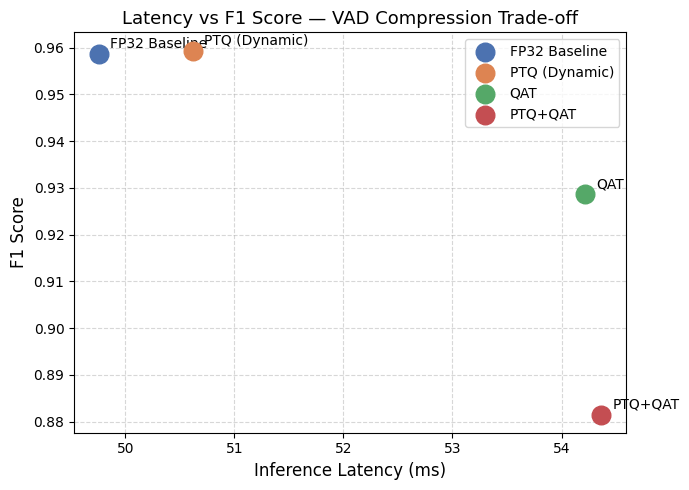

Plot saved to /content/drive/MyDrive/VAD_Compression/latency_vs_f1.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

results = {
    'Model':        ['FP32 Baseline', 'PTQ (Dynamic)', 'QAT',        'PTQ+QAT'],
    'Format':       ['FP32',          'Mixed/INT8',    'Mixed/INT8', 'Mixed/INT8'],
    'Size (MB)':    [fp32_size,        ptq_size,        qat_size,     ptq_qat_size],
    'Latency (ms)': [fp32_latency_median, ptq_latency_median, qat_latency_median, ptq_qat_latency_median],
    'F1 Score':     [fp32_f1,          ptq_f1,          qat_f1,       ptq_qat_f1],
    'Precision':    [fp32_prec,        ptq_prec,        qat_prec,     ptq_qat_prec],
    'Recall':       [fp32_rec,         ptq_rec,         qat_rec,      ptq_qat_rec],
}
df = pd.DataFrame(results)
print("=" * 70)
print("FINAL RESULTS TABLE")
print("=" * 70)
print(df.to_string(index=False))

csv_path = os.path.join(SAVE_DIR, "vad_compression_results.csv")
df.to_csv(csv_path, index=False)
print(f"\nSaved CSV to {csv_path}")

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
for lat, f1, label, color in zip(
    results['Latency (ms)'], results['F1 Score'], results['Model'], colors
):
    ax.scatter(lat, f1, s=180, color=color, zorder=5, label=label)
    ax.annotate(label, (lat, f1), textcoords="offset points", xytext=(8, 4), fontsize=10)

ax.set_xlabel("Inference Latency (ms)", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Latency vs F1 Score — VAD Compression Trade-off", fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plot_path = os.path.join(SAVE_DIR, "latency_vs_f1.png")
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")